In [1]:
import sys
import csv
import os
import json
import torch
import pandas as pd
from dotenv import load_dotenv, find_dotenv

# Load .env
load_dotenv(find_dotenv())

# -------------------------
# Config
# -------------------------
SEED = int(os.environ.get("SEED", 42))
DATA_DIR = os.environ.get("DATA_DIR", "/workspace/data")

raw_data_dir = os.path.join(DATA_DIR, "raw_pubmed_data")
parsed_docs_dir = os.path.join(DATA_DIR, "parsed_docs")
train_csv_path = os.path.join(parsed_docs_dir, "training_final.csv")
test_csv_path = os.path.join(parsed_docs_dir, "test_final.csv")

# -------------------------
# Environment Info
# -------------------------
print(f"SEED: {SEED}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")
print(f"Data dir: {DATA_DIR}")
print(f"Train CSV path: {train_csv_path}")
print(f"Test CSV path: {test_csv_path}")

SEED: 42
CUDA available: True
PyTorch version: 2.2.0
Data dir: /workspace/data
Train CSV path: /workspace/data/parsed_docs/training_final.csv
Test CSV path: /workspace/data/parsed_docs/test_final.csv


## Section Distribution in BioASQ Golden Snippets

In [2]:
DATASET_REGISTRY = {}

# Only load these datasets
ALLOWED_DATASETS = {'13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden', 'training13b'}

print('📂 Loading standard JSON files...')
if not os.path.isdir(raw_data_dir):
    print(f'❌ Directory not found: {raw_data_dir}')
else:
    for filename in sorted(os.listdir(raw_data_dir)):
        if filename.endswith('.json'):
            dataset_name = os.path.splitext(filename)[0]

            if dataset_name not in ALLOWED_DATASETS:  # ← filter here
                print(f'⏭️  Skipping: {filename}')
                continue

            file_path = os.path.join(raw_data_dir, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    raw_data = json.load(f)
                    if isinstance(raw_data, dict) and 'questions' in raw_data:
                        data_list = raw_data['questions']
                    elif isinstance(raw_data, list):
                        data_list = raw_data
                    else:
                        data_list = [raw_data]
                    DATASET_REGISTRY[dataset_name] = {'data': data_list}
                except json.JSONDecodeError as e:
                    print(f'⚠️ Could not parse {filename}: {e}')

print('\n📋 Dataset Inventory:')
for name, meta in DATASET_REGISTRY.items():
    print(f'  [{name}] — {len(meta["data"])} documents')

📂 Loading standard JSON files...

📋 Dataset Inventory:
  [13B1_golden] — 85 documents
  [13B2_golden] — 85 documents
  [13B3_golden] — 85 documents
  [13B4_golden] — 85 documents
  [training13b] — 5389 documents


In [3]:
questions = raw_data["questions"]

records = []

for q in questions:
    for s in q.get("snippets", []):
        records.append({
            "beginSection": s.get("beginSection"),
            "endSection": s.get("endSection")
        })

df_sections = pd.DataFrame(records)

# ----------------------------------
# Count section frequencies
# ----------------------------------

begin_counts = df_sections["beginSection"].value_counts()
end_counts = df_sections["endSection"].value_counts()

print("\nbeginSection counts:")
print(begin_counts)

print("\nendSection counts:")
print(end_counts)


beginSection counts:
beginSection
abstract      57162
title          7623
sections.0     4075
Name: count, dtype: int64

endSection counts:
endSection
abstract      57162
title          7623
sections.0     4075
Name: count, dtype: int64


## Load the CSV and parse the abstracts column

In [4]:
# Read only first 10 rows
df_train_raw = pd.read_csv(train_csv_path, engine="python")
df_train = df_train_raw.copy()

## Basic Dataset Overview

In [5]:
print("Rows:", len(df_train))
print("Columns:", df_train.columns.tolist())

df_train.info()

Rows: 39442
Columns: ['question', 'type', 'title', 'authors', 'text', 'abstract_sections', 'category', 'topic_id', 'confidence', 'pmid', 'source_url', 'n_sources']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39442 entries, 0 to 39441
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   question           39442 non-null  object 
 1   type               39442 non-null  object 
 2   title              39313 non-null  object 
 3   authors            39161 non-null  object 
 4   text               39442 non-null  object 
 5   abstract_sections  39442 non-null  object 
 6   category           39442 non-null  object 
 7   topic_id           39442 non-null  int64  
 8   confidence         39442 non-null  float64
 9   pmid               39442 non-null  int64  
 10  source_url         39442 non-null  object 
 11  n_sources          39442 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 3

In [6]:
df_train.isnull().sum()

question               0
type                   0
title                129
authors              281
text                   0
abstract_sections      0
category               0
topic_id               0
confidence             0
pmid                   0
source_url             0
n_sources              0
dtype: int64

## Unique Questions

In [7]:
df_train["question"].value_counts()

question
Which is the causative agent of malaria?                                                                                                    105
In which proteins is the chromodomain present?                                                                                              102
What tyrosine kinase, involved in a Philadelphia- chromosome positive chronic myelogenous leukemia, is the target of Imatinib (Gleevec)?     79
Is miR-21 related to carcinogenesis?                                                                                                         70
What clinical conditions influence the prognostic after the liver metastasis resection from colorectal cancer patients?                      65
                                                                                                                                           ... 
Does atemoya juice inhibit the CYP1A2 enzyme?                                                                                  

## Category Distribution

In [8]:
df_train["category"].value_counts()

category
Other                    14717
Molecular Biology         4008
Rare Diseases             3205
Immunology                3152
Surgery & Procedures      2161
Diagnostics & Imaging     2114
Pharmacology & Drugs      1749
Genetics & Mutations      1677
Infectious Disease        1547
Cardiology & Heart        1419
Cancer & Oncology         1226
Neurology & Brain         1053
Clinical Guidelines        709
Metabolism & Diabetes      474
Mental Health              231
Name: count, dtype: int64

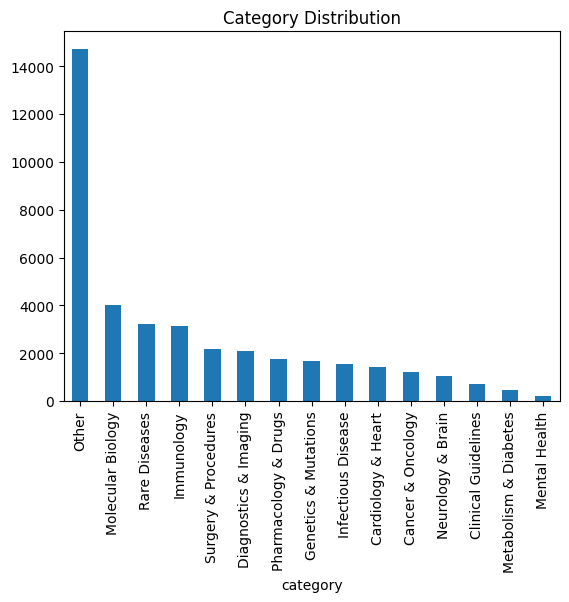

In [9]:
import matplotlib.pyplot as plt

df_train["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

## Question Type Distribution

In [10]:
df_train["type"].value_counts()

type
factoid    11803
yesno      10863
list        9031
summary     7745
Name: count, dtype: int64

## Text Length Analysis (VERY IMPORTANT for chunking)

### Character length

In [11]:
df_train["text_len"] = df_train["text"].str.len()

df_train["text_len"].describe()

count    39442.000000
mean      1426.514147
std        530.105383
min         42.000000
25%       1085.000000
50%       1415.000000
75%       1715.000000
max       9868.000000
Name: text_len, dtype: float64

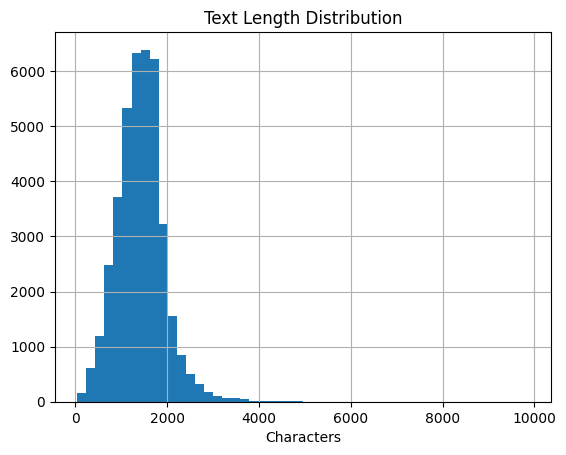

In [12]:
df_train["text_len"].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.show()

### Word length

In [13]:
df_train["text"] = df_train["text"].fillna("")

df_train["word_len"] = df_train["text"].str.split().apply(len)

df_train["word_len"].describe()

count    39442.000000
mean       205.535622
std         77.991398
min          6.000000
25%        154.000000
50%        202.000000
75%        247.000000
max       1480.000000
Name: word_len, dtype: float64

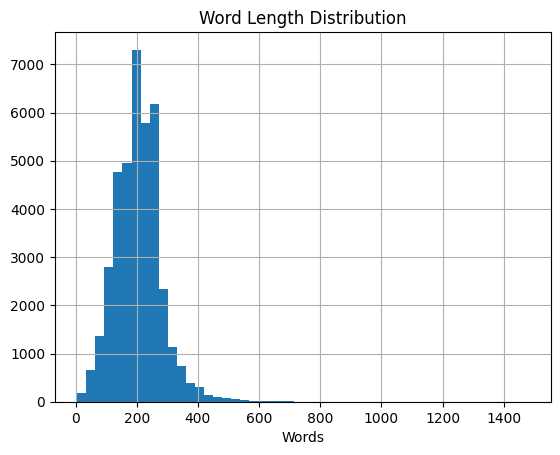

In [14]:
df_train["word_len"].hist(bins=50)
plt.title("Word Length Distribution")
plt.xlabel("Words")
plt.show()

## Inspect Text Quality

In [15]:
for i in range(5):
    print(df_train["text"].iloc[i])
    print("-"*80)

The identification of common variants that contribute to the genesis of human inherited disorders remains a significant challenge. Hirschsprung disease (HSCR) is a multifactorial, non-mendelian disorder in which rare high-penetrance coding sequence mutations in the receptor tyrosine kinase RET contribute to risk in combination with mutations at other genes. We have used family-based association studies to identify a disease interval, and integrated this with comparative and functional genomic analysis to prioritize conserved and functional elements within which mutations can be sought. We now show that a common non-coding RET variant within a conserved enhancer-like sequence in intron 1 is significantly associated with HSCR susceptibility and makes a 20-fold greater contribution to risk than rare alleles do. This mutation reduces in vitro enhancer activity markedly, has low penetrance, has different genetic effects in males and females, and explains several features of the complex inhe

## Token Length Estimation (for embeddings)

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

df_train["tokens"] = df_train["text"].apply(lambda x: len(tokenizer.encode(x)))

df_train["tokens"].describe()

/opt/conda/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


count    39442.000000
mean       329.981517
std        132.509798
min         13.000000
25%        243.000000
50%        321.000000
75%        402.000000
max       2279.000000
Name: tokens, dtype: float64

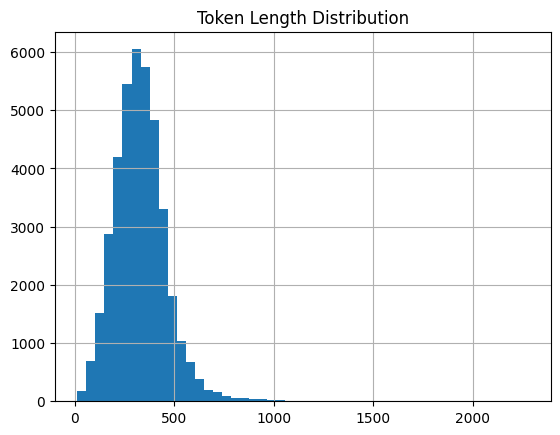

In [17]:
df_train["tokens"].hist(bins=50)
plt.title("Token Length Distribution")
plt.show()

## Best Strategy for Your Dataset

### Only chunk the outliers

In [18]:
df_train["needs_chunking"] = df_train["tokens"] > 400
df_train["needs_chunking"].value_counts()

needs_chunking
False    29380
True     10062
Name: count, dtype: int64